# Conservation score & nucleotide significance
PhastCons is sensitive to "runs" of conserved sites, and is therefore effective for picking out conserved elements. PhyloP, on the other hand, is more appropriate for evaluating signatures of selection at particular nucleotides or classes of nucleotides  
Comparing conservation scores between sig nucleotides and the other nucleotides

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyranges as pr
import re
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from Bio import SeqIO
from scipy.stats import ks_2samp
from matplotlib.lines import Line2D

from matplotlib import font_manager
import matplotlib as mpl

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import pearsonr
from scipy.stats import spearmanr
import re

In [2]:
id_prefix_list = [
	"MYC_GFP_"
]

In [3]:
# remove negative controls that can be mapped to the genome (with bowtie)
mapped_ctrl_path = "/media/scratch/fy2306/projects/base_editing/data/bowtie/all/all_sgrna_seqs.bowtie_hg38.mismatch1.processed.tsv"
mapped_ctrl_df = pd.read_csv(mapped_ctrl_path, sep="\t")
mapped_ctrl_df = mapped_ctrl_df[
    mapped_ctrl_df['id'].str.startswith(('Random', 'Non-targeting-controls', 'AAVS1'))
    & ~(mapped_ctrl_df['id'].str.startswith('AAVS1') & (mapped_ctrl_df['Alignments_NM0'] == 1) & (mapped_ctrl_df['Alignments_NM1'] == 0))
]
mapped_ctrl_list = mapped_ctrl_df["id"].tolist()
print(len(mapped_ctrl_list))
all_ctrl = [
    record.id for record in SeqIO.parse("/media/scratch/fy2306/projects/base_editing/data/bowtie/negative_controls/input/negative_controls.fa", "fasta")
    ]
clean_ctrl_list = list(set(all_ctrl)-set(mapped_ctrl_list))
print(len(clean_ctrl_list))
print(len(all_ctrl))

91
474
565


In [4]:
# randomly group nc sgrnas
def group_and_aggregate(df, group_size, random_state=None):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    num_groups = len(df_shuffled) // group_size
    df_trimmed = df_shuffled.iloc[:num_groups * group_size]
    
    grouped = np.array_split(df_trimmed, num_groups)
    
    aggregated = []
    for group in grouped:
        sgrna_concat = ','.join(group['sgrna'].astype(str))
        avg_lfc = group['per time unit LFC'].mean()
        aggregated.append({
            'sgrna': sgrna_concat,
            'per time unit LFC': avg_lfc
        })
    
    return pd.DataFrame(aggregated)

In [5]:
def conservation_sig_cdf(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate, 
	conservation_method,
	title=None,
	per_time_unit=True, score_smoothing=False):

	score_path = f"/media/scratch/fy2306/projects/base_editing/data/conservation/chr8_myc.{conservation_method}way.wigFix"

	# preprocess
	df_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/{merge_method_nucleotide}/myc_repeats/{win_size}/MYC_U1.gene_summary.txt"
	df = pd.read_csv(df_path, sep="\t")
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df = df[df['id'].str.match(pattern)]
	edited_pos_chr_col = "indel_base_pos_chr"	# nucleotide pos
	df[edited_pos_chr_col] = df['id'].str.extract(pattern)[1].astype(int)	# 1-based

	# merge
	treatment_lfc_columns = [f"{treatment}_vs_{baseline}|neg|lfc" for treatment in treatments]
	treatment_fdr_columns = [f"{treatment}_vs_{baseline}|neg|fdr" for treatment in treatments]
	treatment_fdr_goodsgrna_columns = [f"{treatment}_vs_{baseline}|neg|goodsgrna" for treatment in treatments]
	treatment_fdr_pos_columns = [f"{treatment}_vs_{baseline}|pos|fdr" for treatment in treatments]
	treatment_fdr_pos_goodsgrna_columns = [f"{treatment}_vs_{baseline}|pos|goodsgrna" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df[col] = df[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df["neg|lfc"] = df[treatment_lfc_columns].mean(axis=1)

	# copied from lfc_to_seq
	for fdr_col, goodsgrna_col in zip(treatment_fdr_columns, treatment_fdr_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["neg|fdr"] = df[treatment_fdr_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df["direction"] = df[treatment_lfc_columns].apply(lambda row: (row.gt(0).all() or row.lt(0).all()), axis=1)
	for fdr_col, goodsgrna_col in zip(treatment_fdr_pos_columns, treatment_fdr_pos_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["pos|fdr"] = df[treatment_fdr_pos_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df["fdr"] = df[["neg|fdr", "pos|fdr"]].min(axis=1)

	# add repeats
	rmsk_path = "/media/dna/fy2306/genomes/hg38/RepeatMasker/rmsk.txt"
	rmsk_colnames = ["bin", "swScore", "milliDiv", "milliDel", "milliIns", "genoName", "genoStart", "genoEnd", "genoLeft", "strand", "repName", "repClass", "repFamily", "repStart", "repEnd", "repLeft", "id"]
	rmsk = pd.read_csv(rmsk_path, sep="\t", header=None, names=rmsk_colnames)
	rmsk = rmsk[rmsk['genoName'] == "chr8"]
	# rmsk: 0-based
	rmsk_ranges = pr.PyRanges(rmsk.rename(columns={
	'genoName': 'Chromosome',
	'genoStart': 'Start',
	'genoEnd': 'End'
	}))

	# base_pos: 1-based
	df['Start'] = df[edited_pos_chr_col] - 1
	df['End'] = df['Start'] + 1
	df['Chromosome'] = 'chr8'

	df["orig_index"] = df.index
	df_ranges = pr.PyRanges(df[['Chromosome', 'Start', 'End', 'orig_index']])

	overlap = df_ranges.intersect(rmsk_ranges, how="containment")	# in pyranges: “containment” reports intervals where the overlapping is contained within it, gives you the intervals in self be completely within the intervals in other
	overlap_indices = overlap.df['orig_index'].unique()

	df["indel_repeats"] = False
	df.loc[overlap_indices, "indel_repeats"] = True

	df = df[["id", edited_pos_chr_col, "neg|lfc", "indel_repeats", "fdr", "direction"]]

	# process conservation
	conservation_scores = pd.read_csv(score_path, sep="\t", header=None, names=['chrom', edited_pos_chr_col, 'score'])
	# position: 1-based
	if score_smoothing:
		# rolling
		conservation_scores = conservation_scores.sort_values(by=edited_pos_chr_col).reset_index(drop=True)

		half_win = (int(win_size) // 2)

		smoothed_scores = []

		positions = conservation_scores[edited_pos_chr_col].values
		scores = conservation_scores['score'].values

		for i, pos in enumerate(positions):
			start = pos - half_win	# inclusive
			end = pos + half_win	# inclusive
			
			mask = (positions >= start) & (positions <= end)
			window_scores = scores[mask]
			
			smoothed_scores.append(window_scores.mean() if len(window_scores) > 0 else float('nan'))

		conservation_scores['score'] = smoothed_scores

	df = pd.merge(df, conservation_scores, on=edited_pos_chr_col, how="left")

	# load in lib
	lib_path = f"/media/scratch/fy2306/projects/base_editing/data/grna_type/MYC-lib-for-mageck.type.{myc_var}.organized.txt"
	df_lib = pd.read_csv(lib_path, sep="\t", usecols=[edited_pos_chr_col, cons_col])
	df_lib = df_lib.drop_duplicates(subset=edited_pos_chr_col)
	df = pd.merge(df, df_lib, on=edited_pos_chr_col, how='left')
	df = df[df["indel_repeats"] == False]
	# df: "id", edited_pos_chr_col, "neg|lfc", "indel_repeats", "chrom", "score", cons_col
	print(df[edited_pos_chr_col].duplicated().sum())
	# add promoter annotation
	df.loc[
		(df[edited_pos_chr_col] >= (127736084-1000)) & (df[cons_col] == 'upstream_flanking'),
		cons_col
		] = 'promoter'

	if cons_subset != "all":
		df = df[df[cons_col].isin(cons_subset)]
	print(df['indel_repeats'].value_counts())
	# if isinstance(conservation_threshold, float):
	# 	conservation_threshold = conservation_threshold
	# elif conservation_threshold == "mean":
	# 	# mean of myc gene
	# 	conservation_threshold = df['score'].mean()
	# elif conservation_threshold == "median":
	# 	# median of myc gene
	# 	conservation_threshold = df['score'].median()

	# bins = [float('-inf'), conservation_threshold, float('inf')]
	# labels = [f'(-∞, {conservation_threshold:.2f})', f'[{conservation_threshold:.2f}, ∞)']

	# df['score_bin'] = pd.cut(df['score'], bins=bins, labels=labels, right=False)
	# print(df['score_bin'].value_counts())


	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	df_nc = df_nc[['sgrna', 'per time unit LFC']]

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	print(nc_combined_median_value)

	df["neg|lfc"] = df["neg|lfc"] - nc_combined_median_value

	# add sig column
	df['sig'] = "Other"
	df.loc[(df['fdr'] < 0.05) & (df['direction'] == True), 'sig'] = "Significant"
	print(df['sig'].value_counts())

	# cdf
	plt.figure(figsize=(4,4))

	colors = {
		"Other": "#66CCFE",
		"Significant": "#FF0066"
	}

	for label in ["Significant", "Other"]:
		group_data = df[df['sig'] == label]['score'].sort_values()
		if len(group_data) == 0:
			continue
		cdf = np.arange(1, len(group_data)+1) / len(group_data)

		plt.plot(group_data, cdf, label=f"{label} (N={len(group_data):,})", color=colors[label])

	group_low = df[df['sig'] == 'Other']['score']
	median_low = group_low.median()
	group_high = df[df['sig'] == 'Significant']['score']
	median_high = group_high.median()
	ks_stat, p_value = ks_2samp(group_low, group_high)

	shift = abs(median_high - median_low)

	plt.xlabel(f'Vertebrate conservation ({conservation_method})', fontsize=14)
	plt.ylabel('CDF', fontsize=14)
	if title:
		plt.title(f"{title}", fontsize=13)
	else:
		plt.title(f"{cons_subset}\nscore_smoothing: {score_smoothing}, KS stat={ks_stat:.3f}, p={p_value:.2e}, shift={shift:.2e}", fontsize=13)
	mant, exp = f"{p_value:.2e}".split("e")
	mant = float(mant); exp = int(exp)
	handles = [
		Line2D([], [], linestyle="None", marker=None, color=colors["Significant"],
			label=f'Significant (N={len(df[df.sig=="Significant"]):,})'),
		Line2D([], [], linestyle="None", marker=None, color=colors["Other"],
			label=f'Other (N={len(df[df.sig=="Other"]):,})'),
		Line2D([], [], linestyle="None", marker=None, color="black",
			label=rf"$P={mant:.2f}\times 10^{{{exp}}}$"),
	]
	plt.legend(handles=handles, loc="lower right", frameon=False, fontsize=13,
			handlelength=0, handletextpad=0, labelcolor="linecolor")
	plt.yticks([0, 0.5, 1], fontsize=13)
	plt.xticks(fontsize=13)
	# plt.xlim(0, 1)
	# plt.axvline(x = 0, color='grey', linestyle="--", alpha=0.5)
	# plt.axhline(y = 0.5, color='grey', linestyle="--", alpha=0.5)
	plt.gca().spines['top'].set_visible(False)
	plt.gca().spines['right'].set_visible(False)
	plt.grid(False)
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/conservation/{conservation_method}_sig_cdf.{title}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	# correlation - scatter plot
	print(len(df))
	r, p = pearsonr(df['score'], df['neg|lfc'])
	# r, p = spearmanr(merged_df["LFC_d8"], merged_df["LFC_d20"])
	print(f"Pearson r: {r:.3f}, p-value: {p:.3e}")

	fig, ax = plt.subplots(figsize=(4, 4))

	hb = ax.hexbin(
		x=df['score'],
		y=df['neg|lfc'],
		gridsize=50,      
		cmap="flare",     
		mincnt=1,
		vmin = 1,
		vmax = 50           
	)

	cax = ax.inset_axes([0.05, 0.15, 0.25, 0.03])

	cb = plt.colorbar(hb, cax=cax, orientation='horizontal')
	cb.set_label("bp count", fontsize=10)
	cb.ax.tick_params(labelsize=10)

	sns.despine(ax=ax, top=True, right=True)
	# ax.set_xlim(0, 1)
	ax.set_ylim(-0.175, 0.085)
	# ax.set_xticks([0, 0.5, 1])
	ax.set_yticks([-0.15, -0.075, 0, 0.075])
	ax.tick_params(labelsize=12)
	ax.set_xlabel(f"Conservation: {conservation_method}", fontsize=12)
	ax.set_ylabel("base-pair phenotype score", fontsize=12)
	ax.set_title(title, fontsize=12)

	ax.text(
		0.05, 0.98,
		f"Pearson r = {r:.2f}\n(p = {p:.2e})",
		transform=ax.transAxes,
		fontsize=12,
		verticalalignment='top',
		horizontalalignment='left'
	)

	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)

	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/conservation/{conservation_method}_corr.{title}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()


In [6]:
def conservation_GC(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate, 
	conservation_method,
	title=None,
	per_time_unit=True, score_smoothing=False):

	score_path = f"/media/scratch/fy2306/projects/base_editing/data/conservation/chr8_myc.{conservation_method}way.wigFix"

	# preprocess
	df_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/{merge_method_nucleotide}/myc_repeats/{win_size}/MYC_U1.gene_summary.txt"
	df = pd.read_csv(df_path, sep="\t")
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df = df[df['id'].str.match(pattern)]
	edited_pos_chr_col = "indel_base_pos_chr"	# nucleotide pos
	df[edited_pos_chr_col] = df['id'].str.extract(pattern)[1].astype(int)	# 1-based

	# merge
	treatment_lfc_columns = [f"{treatment}_vs_{baseline}|neg|lfc" for treatment in treatments]
	treatment_fdr_columns = [f"{treatment}_vs_{baseline}|neg|fdr" for treatment in treatments]
	treatment_fdr_goodsgrna_columns = [f"{treatment}_vs_{baseline}|neg|goodsgrna" for treatment in treatments]
	treatment_fdr_pos_columns = [f"{treatment}_vs_{baseline}|pos|fdr" for treatment in treatments]
	treatment_fdr_pos_goodsgrna_columns = [f"{treatment}_vs_{baseline}|pos|goodsgrna" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df[col] = df[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df["neg|lfc"] = df[treatment_lfc_columns].mean(axis=1)

	# copied from lfc_to_seq
	for fdr_col, goodsgrna_col in zip(treatment_fdr_columns, treatment_fdr_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["neg|fdr"] = df[treatment_fdr_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df["direction"] = df[treatment_lfc_columns].apply(lambda row: (row.gt(0).all() or row.lt(0).all()), axis=1)
	for fdr_col, goodsgrna_col in zip(treatment_fdr_pos_columns, treatment_fdr_pos_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["pos|fdr"] = df[treatment_fdr_pos_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df["fdr"] = df[["neg|fdr", "pos|fdr"]].min(axis=1)

	# add repeats
	rmsk_path = "/media/dna/fy2306/genomes/hg38/RepeatMasker/rmsk.txt"
	rmsk_colnames = ["bin", "swScore", "milliDiv", "milliDel", "milliIns", "genoName", "genoStart", "genoEnd", "genoLeft", "strand", "repName", "repClass", "repFamily", "repStart", "repEnd", "repLeft", "id"]
	rmsk = pd.read_csv(rmsk_path, sep="\t", header=None, names=rmsk_colnames)
	rmsk = rmsk[rmsk['genoName'] == "chr8"]
	# rmsk: 0-based
	rmsk_ranges = pr.PyRanges(rmsk.rename(columns={
	'genoName': 'Chromosome',
	'genoStart': 'Start',
	'genoEnd': 'End'
	}))

	# base_pos: 1-based
	df['Start'] = df[edited_pos_chr_col] - 1
	df['End'] = df['Start'] + 1
	df['Chromosome'] = 'chr8'

	df["orig_index"] = df.index
	df_ranges = pr.PyRanges(df[['Chromosome', 'Start', 'End', 'orig_index']])

	overlap = df_ranges.intersect(rmsk_ranges, how="containment")	# in pyranges: “containment” reports intervals where the overlapping is contained within it, gives you the intervals in self be completely within the intervals in other
	overlap_indices = overlap.df['orig_index'].unique()

	df["indel_repeats"] = False
	df.loc[overlap_indices, "indel_repeats"] = True

	df = df[["id", edited_pos_chr_col, "neg|lfc", "indel_repeats", "fdr", "direction"]]

	# process conservation
	conservation_scores = pd.read_csv(score_path, sep="\t", header=None, names=['chrom', edited_pos_chr_col, 'score'])
	# position: 1-based
	if score_smoothing:
		# rolling
		conservation_scores = conservation_scores.sort_values(by=edited_pos_chr_col).reset_index(drop=True)

		half_win = (int(win_size) // 2)

		smoothed_scores = []

		positions = conservation_scores[edited_pos_chr_col].values
		scores = conservation_scores['score'].values

		for i, pos in enumerate(positions):
			start = pos - half_win	# inclusive
			end = pos + half_win	# inclusive
			
			mask = (positions >= start) & (positions <= end)
			window_scores = scores[mask]
			
			smoothed_scores.append(window_scores.mean() if len(window_scores) > 0 else float('nan'))

		conservation_scores['score'] = smoothed_scores

	df = pd.merge(df, conservation_scores, on=edited_pos_chr_col, how="left")

	# load in lib
	lib_path = f"/media/scratch/fy2306/projects/base_editing/data/grna_type/MYC-lib-for-mageck.type.{myc_var}.organized.txt"
	df_lib = pd.read_csv(lib_path, sep="\t", usecols=[edited_pos_chr_col, cons_col])
	df_lib = df_lib.drop_duplicates(subset=edited_pos_chr_col)
	df = pd.merge(df, df_lib, on=edited_pos_chr_col, how='left')
	# df: "id", edited_pos_chr_col, "neg|lfc", "indel_repeats", "chrom", "score", cons_col
	print(df[edited_pos_chr_col].duplicated().sum())
	# add promoter annotation
	df.loc[
		(df[edited_pos_chr_col] >= (127736084-1000)) & (df[cons_col] == 'upstream_flanking'),
		cons_col
		] = 'promoter'

	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	df_nc = df_nc[['sgrna', 'per time unit LFC']]

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	print(nc_combined_median_value)

	df["neg|lfc"] = df["neg|lfc"] - nc_combined_median_value

	# add sig column
	df['sig'] = "Other"
	df.loc[(df['fdr'] < 0.05) & (df['direction'] == True), 'sig'] = "Significant"
	print(df['sig'].value_counts())

	# ----------------------------------------------------------------------

	# load in gc
	gc_path = "/media/scratch/fy2306/projects/base_editing/data/conservation/gc5Base_MYC.tsv"	# wiggle file, 1-based
	df_gc = pd.read_csv(gc_path, sep='\t', header=None, names=['start_pos', 'gc_content'], comment="#")	# 1-based position
	df_gc['start_pos'] = df_gc['start_pos'].astype(int)
	window_size = 5
	df_gc['window_start'] = ((df_gc['start_pos'] - 1) // window_size) * window_size + 1	# 1-based
	df_gc = df_gc.groupby('window_start').agg({
		'gc_content': 'mean'
	}).reset_index()
	print(df_gc.head())

	df[edited_pos_chr_col] = df[edited_pos_chr_col].astype(int)
	df['window_start'] = ((df[edited_pos_chr_col] - 1) // window_size) * window_size + 1  # match each row to window_size-bp window start (1-based)

	# double check
	group_sizes = df.groupby('window_start').size()
	num_exactly_window_size = (group_sizes == window_size).sum()
	num_not_window_size = (group_sizes != window_size).sum()
	print(num_exactly_window_size, num_not_window_size)

	valid_window_starts = group_sizes[group_sizes == window_size].index
	df = df[df["window_start"].isin(valid_window_starts)].copy()

	grouped = df.groupby('window_start').agg({
		'neg|lfc': 'mean',
		'score': 'mean',
	}).reset_index()

	grouped['center_pos'] = grouped['window_start'] + (window_size // 2)
	grouped = pd.merge(grouped, df[[edited_pos_chr_col, cons_col, "indel_repeats"]], left_on = "center_pos", right_on = edited_pos_chr_col, how = "left")

	if cons_subset != "all":
		grouped = grouped[grouped[cons_col].isin(cons_subset)]
	grouped = grouped[grouped["indel_repeats"] == False]

	df_merge = pd.merge(grouped, df_gc[['window_start', 'gc_content']], on='window_start', how='left')

	# partial corr: neg|lfc and conservation score
	df_clean = df_merge.rename(columns={'neg|lfc': 'neg_lfc'})
	pcorr = pg.partial_corr(data=df_clean, x='score', y='neg_lfc', covar='gc_content', method='pearson')
	print(f"Partial correlation between neg|lfc and conservation score (pcorr): {pcorr['r'].values[0]} (p-value: {pcorr['p-val'].values[0]})")

	X = sm.add_constant(df_clean[['gc_content']])

	neg_lfc_resid = sm.OLS(df_clean['neg_lfc'], X).fit().resid
	score_resid = sm.OLS(df_clean['score'], X).fit().resid

	r_partial = stats.pearsonr(neg_lfc_resid, score_resid).statistic

	# Correct p-value for partial correlation
	n = len(df_clean)
	k = 1  # number of controlled variables
	dfree = n - k - 2

	t_stat = r_partial * np.sqrt(dfree / (1 - r_partial**2))
	p_partial = 2 * stats.t.sf(abs(t_stat), df=dfree)

	print(
		f"Partial correlation (manual via residuals): "
		f"r = {r_partial:.4f}, p = {p_partial:.4g}"
	)

	fig, ax = plt.subplots(figsize=(4, 4))

	sm.graphics.plot_partregress(
		endog='neg_lfc',
		exog_i='score',
		exog_others=['gc_content'],
		data=df_clean,
		obs_labels=False,
		markersize=2,
		alpha=0.7,          
		color='#AA66FF',
		ax = ax
	)

	ax.text(
		0.05, 0.98,
		f"Pcorr r = {pcorr['r'].values[0]:.2f}\n(p = {pcorr['p-val'].values[0]:.2e})",
		transform=ax.transAxes,
		fontsize=12,
		verticalalignment='top',
		horizontalalignment='left'
	)

	plt.title(
		f"Partial regression: {conservation_method}, "
		f"{window_size} bp window\n{title}",
		fontsize=13
	)
	plt.xlabel("Score residuals after controlling for GC content", fontsize=11)
	plt.ylabel("neg_lfc residuals after controlling for GC content", fontsize=11)
	plt.gca().spines['top'].set_visible(False)
	plt.gca().spines['right'].set_visible(False)
	ax.tick_params(labelsize=11)
	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/conservation/{conservation_method}_partial_corr.GC.{title}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	# original correlation
	print(len(df_clean))
	r, p = pearsonr(df_clean['score'], df_clean['neg_lfc'])
	# r, p = spearmanr(merged_df["LFC_d8"], merged_df["LFC_d20"])
	print(f"Pearson r: {r:.3f}, p-value: {p:.3e}")

	r, p = pearsonr(df_clean['score'], df_clean['gc_content'])
	# r, p = spearmanr(merged_df["LFC_d8"], merged_df["LFC_d20"])
	print(f"Score and GC content: Pearson r: {r:.3f}, p-value: {p:.3e}")

	r, p = pearsonr(df_clean['neg_lfc'], df_clean['gc_content'])
	# r, p = spearmanr(merged_df["LFC_d8"], merged_df["LFC_d20"])
	print(f"neg_lfc and GC content: Pearson r: {r:.3f}, p-value: {p:.3e}")

0
indel_repeats
False    7957
Name: count, dtype: int64
565
-0.0028773212890625005
sig
Other          7726
Significant     231
Name: count, dtype: int64


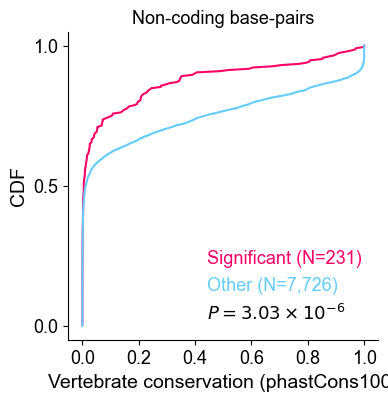

7957
Pearson r: 0.124, p-value: 8.648e-29


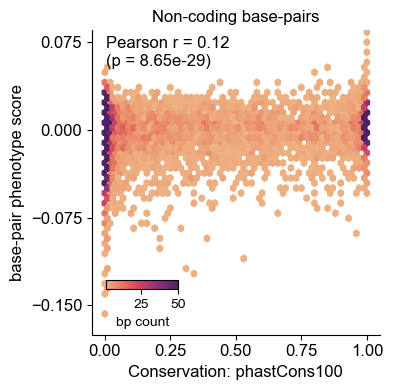

In [8]:
gene = "MYC"
myc_var = "myc2_indel"
cons_col = "indel_consequences_more"
date = "20250416"
test_name = "test-1-standard-nucleotide/test"
nc_test_name = "test-1-standard/test"
merge_method_nucleotide = "mean"
win_size = "4"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
# cons_subset = ["upstream_flanking", "promoter", "5_prime_UTR", "intron_1", "intron_2", "intron_splice", "3_prime_UTR", "coding", "downstream_flanking"]
cons_subset = ["upstream_flanking", "promoter", "5_prime_UTR", "intron_1", "intron_2", "intron_splice", "3_prime_UTR", "downstream_flanking"]
# cons_subset = ["downstream_flanking"]
merge_method_replicate = "mean"
conservation_method = "phastCons100"
conservation_sig_cdf(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate, 
	conservation_method, 
	title = "Non-coding base-pairs",
	per_time_unit=True, score_smoothing=True)


0
565
-0.0028773212890625005
sig
Other          9532
Significant     523
Name: count, dtype: int64
   window_start  gc_content
0     127734051        60.0
1     127734056       100.0
2     127734061        60.0
3     127734066        80.0
4     127734071       100.0
2010 2
Partial correlation between neg|lfc and conservation score (pcorr): 0.11379519189417622 (p-value: 5.469870544682318e-06)
Partial correlation (manual via residuals): r = 0.1138, p = 5.47e-06


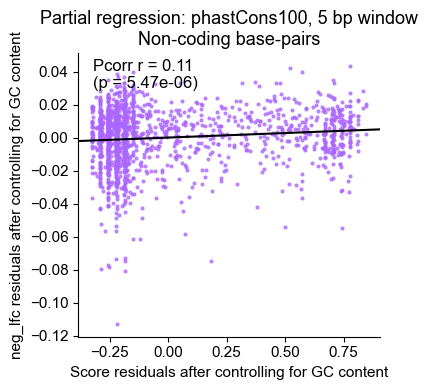

1589
Pearson r: 0.143, p-value: 1.018e-08
Score and GC content: Pearson r: -0.123, p-value: 8.947e-07
neg_lfc and GC content: Pearson r: -0.283, p-value: 1.433e-30


In [33]:
conservation_GC(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate, 
	conservation_method, 
	title = "Non-coding base-pairs",
	per_time_unit=True, score_smoothing=False)